# RetinaNet and Focal Loss for Object Detection

Portfolio version by `@pkim02`.

This notebook is a cleaned project version derived from coursework. The implementation code and executed results are preserved, while submission instructions, personal identifiers, assignment boilerplate, and course-provided image references were removed.

**Project focus:** An object detection project implementing RetinaNet components and focal loss training behavior in PyTorch.


## Implementation Notes

The code cells below contain the implemented model, training, evaluation, and visualization workflow. Most executed outputs are kept so the notebook can be reviewed without rerunning the full experiment.


In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]= "0"  

import datetime
print("This code is written at " + str(datetime.datetime.now()))


This code is written at 2026-04-14 04:57:10.368082


In [2]:
!pip install --upgrade numpy
!pip install --upgrade typing-extensions


     |████████████████████████████████| 17.3 MB 11.4 MB/s eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.19.2
    Uninstalling numpy-1.19.2:
      Successfully uninstalled numpy-1.19.2
     |████████████████████████████████| 45 kB 2.9 MB/s eta 0:00:011
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 3.7.4.3
    Uninstalling typing-extensions-3.7.4.3:
      Successfully uninstalled typing-extensions-3.7.4.3


In [3]:
!pip install albumentations==1.3.1 pycocotools==2.0.7 opencv-python==4.8.0.74 opencv-python-headless==4.8.0.74


     |████████████████████████████████| 125 kB 11.6 MB/s eta 0:00:01
     |████████████████████████████████| 439 kB 13.8 MB/s eta 0:00:01
     |████████████████████████████████| 61.7 MB 12.5 MB/s eta 0:00:01    |████▊                           | 9.0 MB 12.8 MB/s eta 0:00:05
Reason for being yanked: deprecated, use 4.8.0.76
     |████████████████████████████████| 49.1 MB 10.2 MB/s eta 0:00:01     |█████████████                   | 20.1 MB 10.2 MB/s eta 0:00:03
     |████████████████████████████████| 13.9 MB 12.5 MB/s eta 0:00:01
     |████████████████████████████████| 34.5 MB 11.7 MB/s eta 0:00:01    |████████▋                       | 9.3 MB 12.1 MB/s eta 0:00:03     |██████████████████▉             | 20.3 MB 10.7 MB/s eta 0:00:02
     |████████████████████████████████| 220 kB 11.9 MB/s eta 0:00:01
     |████████████████████████████████| 6.9 MB 13.0 MB/s eta 0:00:01
     |████████████████████████████████| 315 kB 12.6 MB/s eta 0:00:01
     |████████████████████████████████| 4.4 MB 12.8 M

In [4]:
import torch
from torch import Tensor, nn
from torch.hub import load_state_dict_from_url
import torch.nn.functional as F

import math
import time
import numpy as np
from typing import *
from PIL import Image
import matplotlib.pyplot as plt

from torchvision.models.detection.transform import GeneralizedRCNNTransform

from codes.modules import *
import warnings

fix_seed(4423)
warnings.filterwarnings(action='ignore')

%matplotlib inline


In [5]:
train_anno_path = "./data/train/Annotations/"
train_data_path = "./data/train/Images/"

test_anno_path = "./data/test/Annotations/"
test_data_path = "./data/test/Images/"

train_transform = [load_obj("albumentations.HorizontalFlip")("p: 0.5")]
train_transform = compose_transforms(train_transform)
test_transform = compose_transforms()

train_dataset = get_pascal(train_anno_path, train_data_path, "train", transforms=train_transform)
test_dataset = get_pascal(test_anno_path, test_data_path, "test", transforms=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn, pin_memory=True)

coco = get_coco_api_from_dataset(test_loader.dataset)
test_evaluator = CocoEvaluator(coco, ["bbox"])


creating index...
index created!


In [6]:
# Define Hyperparameters
num_classes = 21
prior =  0.01

min_size = 800
max_size = 1333
image_mean = [0.485, 0.456, 0.406]
image_std = [0.229, 0.224, 0.225]


Image shape :   torch.Size([3, 375, 500])
Boxes       :
 tensor([[ 32.,  14., 445., 375.]])
Labels      :   tensor([15])


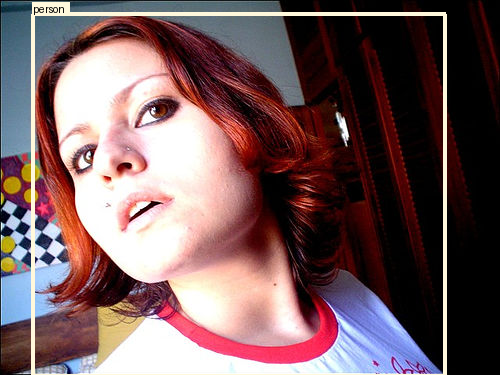

In [7]:
PASCALVOC_LABEL_MAP = ['bg',
                       'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 
                       'bus', 'car', 'cat', 'chair', 'cow',
                       'diningtable', 'dog', 'horse', 'motorbike', 'person', 
                       'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

sample = test_dataset[5]
img = sample[0]
boxes = sample[1]['boxes']
labels = sample[1]['labels']

print("Image shape :  ", img.shape)
print("Boxes       :\n", boxes)
print("Labels      :  ", labels)

img_vis = visualize_bbox(img, boxes, labels, None, PASCALVOC_LABEL_MAP)
img_vis.show()


In [8]:
class Backbone(nn.Module):
    def __init__(self, pretrained = True, freeze_bn = True):
        super(Backbone, self).__init__()
        self.backbone = ResNet(BasicBlock, [2, 2, 2, 2])
        
        # Load pretrained weight
        url_resnet18 = "https://download.pytorch.org/models/resnet18-5c106cde.pth"
        state_dict = load_state_dict_from_url(url_resnet18)
        self.backbone.load_state_dict(state_dict, strict=False)


    def forward(self, xb: Tensor) -> List[Tensor]:
        output_dict = self.backbone(xb)
        out = [
            output_dict["c3"], # [B, C=512, H/8, W/8] 
            output_dict["c4"], # [B, C=1024, H/16, W/16] 
            output_dict["c5"], # [B, C=2048, H/32, W/32] 
        ]
        return out


In [9]:
class FPN(nn.Module):
    def __init__(self, c3_size, c4_size, c5_size, out_channels=256) -> None:
        super(FPN, self).__init__()
        
        ############# Stack convolution layers
        # 1x1 convs to project C3/C4/C5 to 256 channels
        self.c3_conv1 = nn.Conv2d(c3_size, out_channels, kernel_size=1, stride=1, padding=0)
        self.c4_conv1 = nn.Conv2d(c4_size, out_channels, kernel_size=1, stride=1, padding=0)
        self.c5_conv1 = nn.Conv2d(c5_size, out_channels, kernel_size=1, stride=1, padding=0)

        # 3x3 convs to reduce aliasing after top-down fusion
        self.c3_conv3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.c4_conv3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.c5_conv3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)

        # 3x3 convs to create P6 and P7
        self.c6_conv3 = nn.Conv2d(c5_size, out_channels, kernel_size=3, stride=2, padding=1)
        self.c7_conv3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=2, padding=1)

        # Nearest-neighbor upsampling for deeper layer feature maps
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')


        ############# Initialize weights and biases
        # Initialize all new conv layers with N(0, 0.01) and zero bias
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                nn.init.constant_(m.bias, 0.0)

            

    def forward(self, inps: List[Tensor]) -> List[Tensor]:
        C3, C4, C5 = inps
        ############# Stack convolution layers
        # Lateral projections for 256 channel size
        c5_lateral = self.c5_conv1(C5)
        c4_lateral = self.c4_conv1(C4)
        c3_lateral = self.c3_conv1(C3)

        # Top-down fusion
        p5 = self.c5_conv3(c5_lateral)
        p4 = self.c4_conv3(c4_lateral + self.upsample(c5_lateral))
        p3 = self.c3_conv3(c3_lateral + self.upsample(c4_lateral + self.upsample(c5_lateral)))

        # Extra pyramid levels from C5 and P6
        p6 = self.c6_conv3(C5)
        p7 = self.c7_conv3(F.relu(p6))

        return [p3, p4, p5, p6, p7]


In [10]:
class RetinaNetClassSubnet(nn.Module):
    def __init__(self, in_channels: int, out_channels, num_anchors: int, num_classes: int, prior: float) -> None:
        super(RetinaNetClassSubnet, self).__init__()

        self.num_classes = num_classes
        self.num_anchors = num_anchors
        self.class_subnet = nn.Sequential(
            ############# Stack convolution layers, 4 conv layers like retinanet
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

        )
        self.class_subnet_output = nn.Conv2d(
            out_channels, num_anchors * num_classes, kernel_size=3, stride=1, padding=1

        )
        
        ############# Initialize weights and biases
        # Initialize hidden conv layers with N(0, 0.01) and zero bias
        for m in self.class_subnet.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                nn.init.constant_(m.bias, 0.0)

        # same Initialization for output conv weights 
        nn.init.normal_(self.class_subnet_output.weight, mean=0.0, std=0.01)

        # RetinaNet prior bias: b = -log((1-pi)/pi)
        bias_value = -math.log((1.0 - prior) / prior)
        nn.init.constant_(self.class_subnet_output.bias, bias_value)


    def forward(self, feature_maps):
        cls_preds = []
        for features in feature_maps:
            x = self.class_subnet(features)
            x = self.class_subnet_output(x)
            
            N, _, H, W = x.shape
            x = x.view(N, -1, self.num_classes, H, W)
            x = x.permute(0, 3, 4, 1, 2).contiguous().view(N, -1, self.num_classes)
            cls_preds.append(x)
        
        cls_preds = torch.cat([p for p in cls_preds], dim=1)
        return cls_preds


class RetinaNetBoxSubnet(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, num_anchors: int) -> None:
        super(RetinaNetBoxSubnet, self).__init__()

        self.num_anchors = num_anchors
        self.box_subnet = nn.Sequential(
            ############# Stack convolution layers
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

        )

        self.box_subnet_output = nn.Conv2d(
            out_channels, num_anchors * 4, kernel_size=3, stride=1, padding=1

        )
        
        ############# Initialize weights and biases
        # Initialize hidden conv layers with N(0, 0.01) and zero bias
        for m in self.box_subnet.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                nn.init.constant_(m.bias, 0.0)

        # Initialize box regression output layer the same way
        nn.init.normal_(self.box_subnet_output.weight, mean=0.0, std=0.01)
        nn.init.constant_(self.box_subnet_output.bias, 0.0)


    def forward(self, feature_maps):
        bbox_preds = []
        for features in feature_maps:
            x = self.box_subnet(features)
            x = self.box_subnet_output(x)
            
            N, _, H, W = x.shape
            x = x.view(N, -1, 4, H, W)
            x = x.permute(0, 3, 4, 1, 2).contiguous().view(N, -1, 4)    
            bbox_preds.append(x)
        
        bbox_preds = torch.cat([p for p in bbox_preds], dim=1)
        return bbox_preds


In [11]:
class Retinanet(nn.Module):
    def __init__(self) -> None:
        super(Retinanet, self).__init__()
        
        # Backbone 
        self.backbone = Backbone(pretrained=True, freeze_bn=True)
        
        # Construct feature pyramid networks, channel for C345
        fpn_size1 = self.backbone.backbone.layer2[1].conv2.out_channels
        fpn_size2 = self.backbone.backbone.layer3[1].conv2.out_channels
        fpn_size3 = self.backbone.backbone.layer4[1].conv2.out_channels
        
        self.fpn = FPN(fpn_size1, fpn_size2, fpn_size3, 256)
        
        # Generate anchors
        self.anchor_generator = AnchorGenerator()
        num_anchors = self.anchor_generator.num_cell_anchors[0]
        
        # Build two sub-networks: Classification net and Bbox regression net
        self.classification_head = RetinaNetClassSubnet(256, 256, num_anchors, num_classes, prior)
        self.regression_head = RetinaNetBoxSubnet(256, 256, num_anchors)
        
        self.transform = GeneralizedRCNNTransform(min_size, max_size, image_mean, image_std)


    def forward(self, images: List[Tensor]) -> Dict[str, Tensor]:
        # Foward pass of the Model
        feature_maps = self.backbone(images.tensors)
        feature_maps = self.fpn(feature_maps)
        
        # outputs        
        outputs = {}
        outputs['cls_preds'] = self.classification_head(feature_maps)
        outputs['bbox_preds'] = self.regression_head(feature_maps)
        
        # Generate anchors for the images
        anchors = self.anchor_generator(images, feature_maps)
        return (outputs, anchors)
    
    
    def predict(self, images: List[Tensor]) -> List[Dict[str, Tensor]]:
        original_image_sizes = []
        for img in images:
            original_image_sizes.append((img.shape[-2:][0], img.shape[-2:][1]))
            
        images, _       = self.transform(images, None)
        feature_maps    = self.backbone(images.tensors)
        feature_maps    = self.fpn(feature_maps)
        
        outputs = {}
        outputs['cls_preds'] = self.classification_head(feature_maps)
        outputs['bbox_preds'] = self.regression_head(feature_maps)
        
        anchors = self.anchor_generator(images, feature_maps)
        
        #compute the detections
        detections  = process_detections(outputs, anchors, images.image_sizes)
        preds       = self.transform.postprocess(detections, images.image_sizes, original_image_sizes)
        return preds


In [12]:
# Instantiate modules
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Retinanet()
model = model.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to /root/.cache/torch/hub/checkpoints/resnet18-5c106cde.pth


In [13]:
print("-"*30)
print("[FPN]")
print(f"Mean of weight : {model.fpn.c3_conv1.weight.mean().item():.2f}") # zero
print(f"Std of weight  : {model.fpn.c3_conv1.weight.std().item():.2f}") # 0.01
print(f"Sum of bias    : {model.fpn.c3_conv1.bias.sum().item():.2f}") # zero

print("-"*30)
print("[Classification Subnet]")
print(f"Mean of weight : {model.classification_head.class_subnet[0].weight.mean().item():.2f}") # zero
print(f"Std of weight  : {model.classification_head.class_subnet[0].weight.std().item():.2f}") # 0.01
print(f"Sum of bias    : {model.classification_head.class_subnet[0].bias.sum().item():.2f}") # zero

print("-"*30)
print("[The output layer of Classification Subnet]")
print(f"Mean of weight : {model.classification_head.class_subnet_output.weight.mean().item():.2f}") # zero
print(f"Std of weight  : {model.classification_head.class_subnet_output.weight.std().item():.2f}") # 0.01
print(f"Sum of bias    : {model.classification_head.class_subnet_output.bias.sum().item():.2f}") # not zero!

print("-"*30)
print("[Regression Subnet]")
print(f"Mean of weight : {model.regression_head.box_subnet[0].weight.mean().item():.2f}") # zero
print(f"Std of weight  : {model.regression_head.box_subnet[0].weight.std().item():.2f}") # 0.01
print(f"Sum of bias    : {model.regression_head.box_subnet[0].bias.sum().item():.2f}") # zero


------------------------------
[FPN]
Mean of weight : 0.00
Std of weight  : 0.01
Sum of bias    : 0.00
------------------------------
[Classification Subnet]
Mean of weight : 0.00
Std of weight  : 0.01
Sum of bias    : 0.00
------------------------------
[The output layer of Classification Subnet]
Mean of weight : 0.00
Std of weight  : 0.01
Sum of bias    : -868.48
------------------------------
[Regression Subnet]
Mean of weight : 0.00
Std of weight  : 0.01
Sum of bias    : 0.00


In [14]:
class RetinaNetLosses(nn.Module):
    def __init__(self) -> None:
        super(RetinaNetLosses, self).__init__()
        self.alpha = 0.25
        self.gamma = 2.0
        self.beta  = 0.1

    def focal_loss(self, clas_pred: Tensor, clas_tgt: Tensor) -> Tensor:
        # Convert logits to probabilities for focal weighting
        p = torch.sigmoid(clas_pred)

        # Standard binary cross-entropy per class, per anchor
        ce_loss = F.binary_cross_entropy_with_logits(clas_pred, clas_tgt, reduction='none')

        # p_t is the predicted probability of the true class
        p_t = p * clas_tgt + (1.0 - p) * (1.0 - clas_tgt)

        # Alpha balancing term for positive/negative imbalance
        alpha_t = self.alpha * clas_tgt + (1.0 - self.alpha) * (1.0 - clas_tgt)

        # Focal loss down-weights easy examples using (1 - p_t)^gamma
        focal_loss = alpha_t * ((1.0 - p_t) ** self.gamma) * ce_loss
        focal_loss = focal_loss.sum()
        
        return focal_loss
    
    def smooth_l1_loss(self, inp: Tensor, target: Tensor) -> torch.Tensor:
        # Difference between predicted box offsets and target offsets
        diff = inp - target
        abs_diff = diff.abs()

        # Piecewise Smooth L1 with beta threshold
        loss = torch.where(
            abs_diff < self.beta,
            0.5 * (diff ** 2) / self.beta,
            abs_diff - 0.5 * self.beta
        )
        
        return loss.sum()

    def calculate_loss(self, anchors: Tensor, clas_pred: Tensor, bbox_pred: Tensor, clas_tgt: Tensor, bbox_tgt: Tensor) -> Tuple[Tensor, Tensor]:
    
        matches = matcher(anchors, bbox_tgt)
        bbox_mask = matches >= 0

        if bbox_mask.sum() != 0:
            bbox_pred = bbox_pred[bbox_mask]
            bbox_tgt = bbox_tgt[matches[bbox_mask]]
            # match the targets with anchors to get the bboxes
            bbox_tgt = bbox_2_activ(bbox_tgt, anchors[bbox_mask])
            bb_loss = self.smooth_l1_loss(bbox_pred, bbox_tgt)
        else:
            bb_loss = torch.tensor(0.0).to(bbox_pred.device)

        # filtering mask to filter `ignore` classes from the class predicitons
        matches.add_(1)
        clas_mask = matches >= 0
        clas_pred = clas_pred[clas_mask]

        # [0, num_classes) -> [1, num_classes]
        clas_pred = clas_pred + 1 
        
        # add 0 label for the background class
        clas_tgt = torch.cat([clas_tgt.new_zeros(1).long(), clas_tgt])
        clas_tgt = clas_tgt[matches[clas_mask]]

        # no loss for the first(background) class
        clas_tgt = F.one_hot(clas_tgt, num_classes=num_classes + 1)[:, 1:]
        clas_tgt = clas_tgt.to(clas_pred.dtype)

        # classification loss
        clas_loss = self.focal_loss(clas_pred, clas_tgt)

        # Normalize Loss with num foregrounds
        bb_loss.to(clas_loss.dtype).div_(torch.clamp(bbox_mask.sum(), min=1.0))
        clas_loss.div_(torch.clamp(bbox_mask.sum(), min=1.0))

        return bb_loss, clas_loss

    def forward(self, targets: List[Dict[str, Tensor]], head_outputs: List[Tensor], anchors: List[Tensor]) -> Dict[str, Tensor]:
        # extract the class_predictions & bbox_predictions from the RetinaNet Head Outputs
        clas_preds, bbox_preds = head_outputs["cls_preds"], head_outputs["bbox_preds"]
        losses = {}
        # List to store losses
        classification_losses = []
        regression_losses = []

        for cls_pred, bb_pred, targs, ancs in zip(clas_preds, bbox_preds, targets, anchors):
            # Extract the Labels & boxes from the targets
            class_targs, bbox_targs = targs["labels"], targs["boxes"]
            # Compute losses
            regression_loss, classification_loss = self.calculate_loss(ancs, cls_pred, bb_pred, class_targs, bbox_targs)
            # Append Losses of all the batches
            classification_losses.append(classification_loss)
            regression_losses.append(regression_loss)

        # Average the losses
        classification_losses = sum(classification_losses) / len(targets)
        regression_losses = sum(regression_losses) / len(targets)

        # Add losses to dictionary
        losses["classification_loss"] = classification_losses
        losses["regression_loss"] = regression_losses
        return losses


In [15]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
retinanet_loss = RetinaNetLosses()

transform = GeneralizedRCNNTransform(min_size, max_size, image_mean, image_std)
num_epochs = 10


In [16]:
# Train the model
start = time.time()

for epoch in range(num_epochs):
    total_loss = 0
    total_loss_cls = 0
    total_loss_reg = 0

    print("*************** Train ***************")
    model.train()
    for i, batch in enumerate(train_loader):
        images, targets, _ = batch  
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]  

        images, targets = transform(images, targets)
        outputs, anchors = model(images) 
        
        loss_dict = retinanet_loss(targets, outputs, anchors)
        losses = sum(loss for loss in loss_dict.values())
        total_loss += losses.item()
        total_loss_cls += loss_dict['classification_loss'].item()
        total_loss_reg += loss_dict['regression_loss'].item()

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        if (i+1) % 100 == 0:
            print('Epoch [%d/%d], Iter [%d,%d] Loss:%.4f, cls_loss:%.4f, reg_loss:%.4f, time: %d' \
                % (epoch+1, num_epochs, i+1, len(train_loader), total_loss/(i+1), total_loss_cls/(i+1), total_loss_reg/(i+1), time.time()-start))
    
    print("*************** Test ***************")
    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            images, targets, _ = batch
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]  
            
            preds = model.predict(images)
            
            res = {t["image_id"].item(): o for t, o in zip(targets, preds)}
            test_evaluator.update(res)
            
    test_evaluator.accumulate()
    test_evaluator.summarize()

    metric = test_evaluator.coco_eval["bbox"].stats[1]
    print(f"AP @(IoU=0.5): {metric*100:.2f}%")


*************** Train ***************
Epoch [1/10], Iter [100,300] Loss:1.7305, cls_loss:1.2828, reg_loss:0.4477, time: 87
Epoch [1/10], Iter [200,300] Loss:1.4479, cls_loss:1.0216, reg_loss:0.4263, time: 176
Epoch [1/10], Iter [300,300] Loss:1.3194, cls_loss:0.9150, reg_loss:0.4044, time: 265
*************** Test ***************
AP @(IoU=0.5): 24.81%
*************** Train ***************
Epoch [2/10], Iter [100,300] Loss:0.9439, cls_loss:0.6298, reg_loss:0.3141, time: 429
Epoch [2/10], Iter [200,300] Loss:0.9569, cls_loss:0.6470, reg_loss:0.3100, time: 523
Epoch [2/10], Iter [300,300] Loss:0.9340, cls_loss:0.6326, reg_loss:0.3014, time: 619
*************** Test ***************
AP @(IoU=0.5): 24.85%
*************** Train ***************
Epoch [3/10], Iter [100,300] Loss:0.8292, cls_loss:0.5622, reg_loss:0.2669, time: 795
Epoch [3/10], Iter [200,300] Loss:0.8191, cls_loss:0.5572, reg_loss:0.2619, time: 894
Epoch [3/10], Iter [300,300] Loss:0.8099, cls_loss:0.5521, reg_loss:0.2578, time:

## Results To Review

See the preserved output cells for training curves, metrics, predictions, visualizations, or heatmaps depending on the project. The repository README summarizes the main implementation choices and paper references.
